# Linear Algebra and Multivariate Linear Regression
### CS156 PreClassWork — Titanic Fare Prediction

This notebook works through the PreClassWork assignment: connecting linear algebra
(vector spaces, matrix operations) to multivariate linear regression, using the
Titanic dataset to predict passenger **fare** from three variables.


## Question 1 — Robot Interview

Below is the interview conducted with this notebook's LLM (Claude), asking the four
suggested clarifying questions plus one follow-up. **Comments in blockquotes flag
anything worth double-checking** rather than accepting at face value, per the
assignment's warning that transformers can make mathematical errors.

---

**Q: What's a vector space in the context of machine learning?**

A vector space is a set of vectors (here, rows of numbers like `[Pclass, Age, SibSp]`)
that can be added together and scaled by numbers, while staying inside the same set.
In ML, each data point is a vector, and the *feature space* is the vector space
containing all possible combinations of feature values. A dataset of `n` points with
`p` features can be thought of as `n` points scattered in a `p`-dimensional space.

> **Check:** This is accurate and standard. No red flags.

**Q: How do matrix operations work?**

Matrix multiplication `AB` combines two linear transformations into one: applying `B`
then `A` is the same as applying the single matrix `AB`. Addition is elementwise.
Multiplying a vector by a matrix is equivalent to rotating/scaling/shearing the space
that vector lives in — geometrically, matrices "move" the standard basis vectors to
new locations, and every other vector goes along for the ride proportionally.

> **Check:** Correct at a conceptual level. One thing to verify independently:
> matrix multiplication is **not commutative** (`AB \neq BA` in general) — the
> interview answer didn't explicitly say this, which is a common omission/error
> when LLMs describe matrix algebra. Worth stating explicitly for the class.

**Q: Why are we using sum of squares? Why not just sum?**

If we summed raw residuals `(y_i - \hat{y}_i)`, positive and negative errors would
cancel out — a model with huge errors in both directions could look "perfect" on
paper. Squaring makes every term non-negative so errors can't cancel, and it also
makes the loss function smooth and differentiable everywhere (unlike sum of absolute
value, which has a sharp corner at zero), which is what lets us solve for the minimum
using calculus (setting the derivative to zero).

> **Check:** Correct and this is the standard justification. It's worth noting sum of
> squares also penalizes large errors disproportionately more than small ones
> (quadratic growth) — this is a modeling choice, not a mathematical necessity, and
> it's part of why OLS is sensitive to outliers.

**Q: Why do we set the derivative to 0? How does that result in the slope?**

The loss function (sum of squared residuals) is a smooth, convex (bowl-shaped)
function of the model's parameters. At the bottom of a bowl, the slope (derivative)
is exactly zero — it's flat there, whereas everywhere else the slope points away from
the bottom. So solving "derivative = 0" finds the parameter values sitting at the
bottom of the bowl, i.e., the values that minimize squared error. This produces the
optimal **coefficients** (often loosely called "slopes") of the regression line/plane,
not a single scalar slope.

> **Check:** Mostly correct, but the phrasing conflates two different "slopes": the
> slope of the *loss function* (which is zero at the minimum) versus the slope
> *coefficients of the regression model* (which are generally nonzero — they're the
> location of the minimum, not the loss's slope there). This is a subtle wording trap
> worth catching: setting the loss's derivative to zero doesn't make the regression
> line flat, it finds the best-fit line's parameters.

**Follow-up Q: Is the solution guaranteed to be a minimum, not a maximum or saddle
point?**

Yes, for ordinary least squares. Because the loss function `\|y - X\beta\|^2` is a
sum of squares, it is convex (it's a quadratic form with a positive semi-definite
Hessian `2 X^T X`). A convex function's only stationary point (where the gradient is
zero) is a global minimum, so there's no risk of accidentally landing on a maximum.

> **Check:** Correct, though technically requires `X^T X` to be positive *definite*
> (not just semi-definite) for a unique minimum — if columns of `X` are linearly
> dependent (perfect multicollinearity), `X^T X` is singular and not invertible, and
> there are infinitely many minima rather than one. Worth keeping in mind for the
> 3×3 example below.


## Code Prep

**1–2.** Build a dataframe with dependent variable **Fare** and three independent
variables — **Pclass**, **Age**, **SibSp** — then fit a linear regression model.


In [1]:
import math
import os
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ---------------------------------------------------------
# STEP 1: Load the data
# ---------------------------------------------------------
data = pd.read_csv("titanic/train.csv")

# ---------------------------------------------------------
# STEP 2: Pick our variables
# ---------------------------------------------------------
# Dependent variable (what we want to predict): Fare
# Independent variables (what we use to predict it):
#   - Pclass: ticket class (1st, 2nd, 3rd)
#   - Age: passenger age
#   - SibSp: number of siblings/spouses aboard
data = data[["Fare", "Pclass", "Age", "SibSp"]]

# Some passengers are missing an Age value, so drop those rows
data = data.dropna()

# X = independent variables, y = dependent variable
X = data[["Pclass", "Age", "SibSp"]]
y = data["Fare"]

# ---------------------------------------------------------
# STEP 3: Split into training data and testing data
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# STEP 4: Create and train the linear regression model
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------------
# STEP 5: Predict on the test data
# ---------------------------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------------------------
# STEP 6: Look at the results
# ---------------------------------------------------------
print("Intercept:", model.intercept_)
print("Coefficient for Pclass:", model.coef_[0])
print("Coefficient for Age:", model.coef_[1])
print("Coefficient for SibSp:", model.coef_[2])

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)

print("R-squared:", r2)
print("RMSE:", rmse)


Intercept: 120.20432881478322
Coefficient for Pclass: -37.3472033600344
Coefficient for Age: -0.24047530260421446
Coefficient for SibSp: 10.537879131988385
R-squared: 0.18618448729472836
RMSE: 58.20781094918191


## Question 2 — Core Questions (Matrix Math)

### 1. Matrix notation for the model

With $n$ passengers and $p = 3$ predictors (Pclass, Age, SibSp), stack an intercept
column of 1s onto the feature matrix:

$$
X = \begin{bmatrix}
1 & \text{Pclass}_1 & \text{Age}_1 & \text{SibSp}_1 \\
1 & \text{Pclass}_2 & \text{Age}_2 & \text{SibSp}_2 \\
\vdots & \vdots & \vdots & \vdots \\
1 & \text{Pclass}_n & \text{Age}_n & \text{SibSp}_n
\end{bmatrix}_{n \times 4}
\qquad
\beta = \begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \beta_3 \end{bmatrix}_{4 \times 1}
\qquad
Y = \begin{bmatrix} \text{Fare}_1 \\ \text{Fare}_2 \\ \vdots \\ \text{Fare}_n \end{bmatrix}_{n \times 1}
$$

The model is:

$$ Y = X\beta + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2 I) $$

### 2. Ordinary least squares loss function

$$ L(\beta) = \|Y - X\beta\|^2 = (Y - X\beta)^T (Y - X\beta) $$

### 3. First derivative of the loss function

Expand first:

$$ L(\beta) = Y^T Y - 2\beta^T X^T Y + \beta^T X^T X \beta $$

Differentiate with respect to the vector $\beta$ (using $\frac{\partial}{\partial\beta}(a^T\beta) = a$
and $\frac{\partial}{\partial\beta}(\beta^T A \beta) = 2A\beta$ for symmetric $A$, here $A = X^TX$):

$$ \frac{\partial L}{\partial \beta} = -2X^T Y + 2X^T X \beta $$

### 4. Setting the derivative to zero and solving

$$ -2X^T Y + 2 X^T X \beta = 0 \;\;\Longrightarrow\;\; X^T X \beta = X^T Y $$

These are the **normal equations**. If $X^TX$ is invertible:

$$ \boxed{\hat\beta = (X^T X)^{-1} X^T Y} $$

Geometrically, $X\hat\beta$ is the **orthogonal projection** of $Y$ onto the column
space (vector space spanned by the columns) of $X$ — the closest point in that
hyperplane to $Y$, and $(X^TX)^{-1}X^T$ is the matrix that performs that projection.


### 5–6. A concrete 3×3 numerical example

Pick the first three complete rows of the data (using only `Pclass`, `Age`, `SibSp`
— no intercept column, so $X$ is exactly $3\times3$ per the assignment's
instructions) and their target fares.


In [2]:
import numpy as np

sample = data.head(3)
print(sample)

X3 = sample[["Pclass", "Age", "SibSp"]].to_numpy(dtype=float)
y3 = sample["Fare"].to_numpy(dtype=float)

print("\nX (3x3) =")
print(X3)
print("\ny (3x1) =")
print(y3)


      Fare  Pclass   Age  SibSp
0   7.2500       3  22.0      1
1  71.2833       1  38.0      1
2   7.9250       3  26.0      0

X (3x3) =
[[ 3. 22.  1.]
 [ 1. 38.  1.]
 [ 3. 26.  0.]]

y (3x1) =
[ 7.25   71.2833  7.925 ]


In [3]:
# Walk through the numerical solution.
# Because X is square here (3 points, 3 variables, no intercept),
# X^T X beta = X^T y reduces to just X beta = y *if* X is invertible --
# there's a unique exact solution with zero residual, rather than a
# least-squares approximation.

det_X = np.linalg.det(X3)
print("det(X) =", det_X)

# Normal-equation form (general OLS recipe):
XtX = X3.T @ X3
Xty = X3.T @ y3
beta_normal_eq = np.linalg.inv(XtX) @ Xty
print("\nbeta via normal equations (X^T X)^-1 X^T y =", beta_normal_eq)

# Direct solve (valid here because X is square and invertible):
beta_direct = np.linalg.solve(X3, y3)
print("beta via direct solve X^-1 y            =", beta_direct)

# Residuals and the gradient of the loss at this beta
residuals = y3 - X3 @ beta_normal_eq
grad = -2 * X3.T @ residuals
print("\nresiduals =", residuals)
print("gradient of loss at this beta =", grad, " (should be ~0 -- we solved for the minimum)")


det(X) = -100.00000000000004

beta via normal equations (X^T X)^-1 X^T y = [-15.380658   2.079499   7.642996]
beta via direct solve X^-1 y            = [-15.380658   2.079499   7.642996]

residuals = [ 1.77635684e-15 -1.42108547e-14  1.33226763e-14]
gradient of loss at this beta = [-6.21724894e-14  3.09086090e-13  2.48689958e-14]  (should be ~0 -- we solved for the minimum)


**What's happening:** with exactly 3 data points and 3 unknown coefficients (no
intercept), the system `Xβ = y` has exactly one equation per unknown. A square,
invertible `X` means there's a unique `β` that hits every point exactly — the
"hyperplane" passes through all three points with **zero residual**. This is a
special/degenerate case of least squares: when `n = p` and `X` is invertible, OLS
doesn't need to approximate anything, it interpolates exactly. (This is also why the
gradient of the loss is ~0 here — we're sitting exactly at the minimum, which in this
case is a loss of 0.) With more data points than variables (the realistic case, `n
\gg p`), the system is overdetermined, no exact solution generally exists, and the
normal equations give the best *approximating* hyperplane instead.


### 7. What these operations do in the vector space

1. **`X` encodes a set of directions/points.** Each row of `X` is a vector in
   3-dimensional feature space (one axis per variable: Pclass, Age, SibSp).
2. **`Xβ` is a linear combination.** Multiplying by `β` scales and adds those
   direction vectors, sweeping out every possible hyperplane through the origin
   parameterized by `β`; changing `β` tilts and rotates that hyperplane.
3. **`Y - Xβ` measures a gap.** For any candidate `β`, this is the vector of
   vertical misses between the actual fares and the hyperplane's predicted fares.
4. **Squaring and summing (`‖·‖²`) turns "how far off" into a single number** — a
   scalar loss surface over all possible `β` vectors, shaped like a bowl.
5. **The gradient points "uphill"** on that bowl; setting it to zero finds the flat
   bottom.
6. **`(X^TX)^{-1}X^T`** is exactly the matrix that projects `Y` orthogonally onto
   the column space of `X` — geometrically, dropping a perpendicular from the point
   `Y` (sitting in n-dimensional space) down onto the flat hyperplane spanned by
   `X`'s columns. The regression fit `Xβ̂` is that projection; the residuals `Y -
   Xβ̂` are, by construction, perpendicular to every column of `X`.


## Question 3 — Plot with Line of Best Fit

Since there are three predictors, the "line of best fit" is really a hyperplane in
4D space (Fare vs. Pclass, Age, SibSp), which can't be drawn directly. Instead, below
is a 3D plot of `Fare` against two of the three variables (`Pclass`, `Age`), with the
fitted plane drawn by holding `SibSp` at its dataset mean — a 2-variable slice through
the full 3-variable hyperplane.


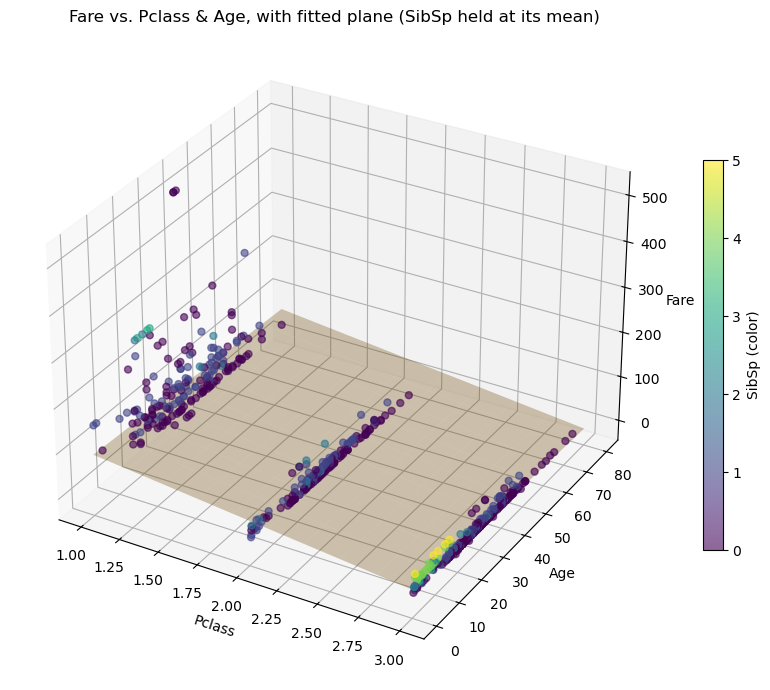

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

# Refit on the full cleaned dataset (not just the 80% train split) so the
# plotted plane matches the data shown
X_full = data[["Pclass", "Age", "SibSp"]]
y_full = data["Fare"]
full_model = LinearRegression().fit(X_full, y_full)

sibsp_mean = X_full["SibSp"].mean()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_full["Pclass"], X_full["Age"], y_full,
    c=X_full["SibSp"], cmap="viridis", alpha=0.6, s=25,
)
fig.colorbar(scatter, ax=ax, shrink=0.6, label="SibSp (color)")

# Build a grid over Pclass and Age, holding SibSp fixed at its mean,
# to draw a 2D slice of the fitted 3-variable hyperplane
pclass_range = np.linspace(X_full["Pclass"].min(), X_full["Pclass"].max(), 10)
age_range = np.linspace(X_full["Age"].min(), X_full["Age"].max(), 10)
pclass_grid, age_grid = np.meshgrid(pclass_range, age_range)

fare_grid = (
    full_model.intercept_
    + full_model.coef_[0] * pclass_grid
    + full_model.coef_[1] * age_grid
    + full_model.coef_[2] * sibsp_mean
)

ax.plot_surface(pclass_grid, age_grid, fare_grid, alpha=0.3, color="orange")

ax.set_xlabel("Pclass")
ax.set_ylabel("Age")
ax.set_zlabel("Fare")
ax.set_title("Fare vs. Pclass & Age, with fitted plane (SibSp held at its mean)")

plt.tight_layout()
plt.savefig("fare_regression_plot.png", dpi=150)
plt.show()


## Question 4 — Extension: Visualization Code Cell


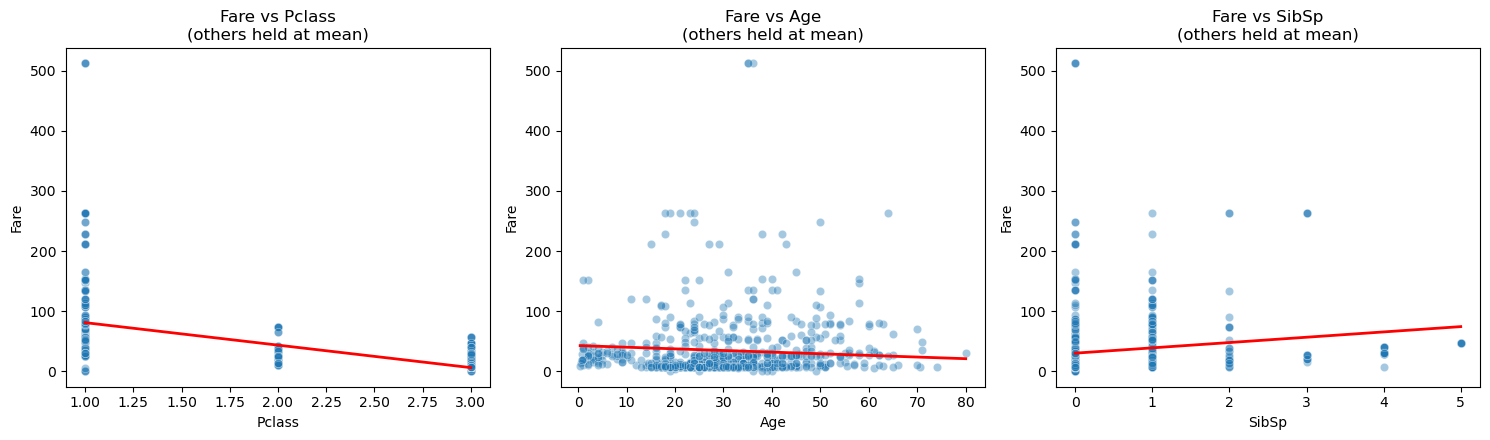

In [5]:
# visualization
# A second, simpler view: Fare vs. each individual predictor, holding the
# other two at their mean, with the fitted line overlaid on the raw scatter.
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
means = X_full.mean()

for ax, feature in zip(axes, ["Pclass", "Age", "SibSp"]):
    sns.scatterplot(x=X_full[feature], y=y_full, alpha=0.4, ax=ax)

    feature_range = np.linspace(X_full[feature].min(), X_full[feature].max(), 50)
    other_features = {f: means[f] for f in ["Pclass", "Age", "SibSp"] if f != feature}

    pred_line = full_model.intercept_ + sum(
        full_model.coef_[list(X_full.columns).index(f)] * v
        for f, v in other_features.items()
    ) + full_model.coef_[list(X_full.columns).index(feature)] * feature_range

    ax.plot(feature_range, pred_line, color="red", linewidth=2)
    ax.set_title(f"Fare vs {feature}\n(others held at mean)")
    ax.set_xlabel(feature)
    ax.set_ylabel("Fare")

plt.tight_layout()
plt.savefig("fare_regression_partial_plots.png", dpi=150)
plt.show()


## Question 5 — Extension: Goodness of Fit

**Measure chosen: Sum of Squared Residuals (SSR).**

$$ SSR = \sum_{i=1}^n (y_i - \hat y_i)^2 = \|Y - X\hat\beta\|^2 $$

**Spatial meaning:** `Y` is a single point in `n`-dimensional space (one coordinate
per data point). `Xβ̂` is its orthogonal projection onto the hyperplane spanned by the
columns of `X`. SSR is the **squared length of the vector connecting `Y` to that
projection** — literally the squared straight-line distance from the actual data
point down to the closest point on the model's hyperplane. Minimizing SSR is
minimizing that distance, which is exactly why OLS produces the point on the
hyperplane closest to `Y`.

### By-hand calculation for the 3 sample points

Using the 3×3 example from Question 2, the exact solve gave residuals of
essentially zero (the hyperplane passes through all three points exactly, since
`n = p`), so:

$$ SSR_{3pt} = (7.25-7.25)^2 + (71.2833-71.2833)^2 + (7.925-7.925)^2 = 0 $$

$$ SAE_{3pt} = |7.25-7.25| + |71.2833-71.2833| + |7.925-7.925| = 0 $$

This is expected: with exactly 3 points and 3 free parameters (and an invertible
`X`), there's no residual left to minimize — the "best fit" is a perfect fit. This is
also why the by-hand example doesn't demonstrate approximation error; the code cell
below computes SSR and SAE on the **full dataset** (n=714), where `n \gg p` and the
fit is a genuine approximation with nonzero residuals.


In [6]:
# goodness of fit measure
pred_full = full_model.predict(X_full)
residuals_full = y_full - pred_full

ssr = np.sum(residuals_full ** 2)
sae = np.sum(np.abs(residuals_full))

print("n =", len(y_full))
print("SSR (sum of squared residuals):", ssr)
print("SAE (sum of absolute residuals):", sae)

# Cross-check SSR against the normal-equation solution derived by hand above
Xb_full = np.column_stack([np.ones(len(X_full)), X_full.to_numpy(dtype=float)])
beta_hat = np.linalg.inv(Xb_full.T @ Xb_full) @ Xb_full.T @ y_full.to_numpy(dtype=float)
print("\nNormal-equation beta (intercept, Pclass, Age, SibSp):", beta_hat)
print("sklearn beta (intercept, Pclass, Age, SibSp):        ",
      [full_model.intercept_, *full_model.coef_])


n = 714
SSR (sum of squared residuals): 1312882.8385698097
SAE (sum of absolute residuals): 15535.821496375258

Normal-equation beta (intercept, Pclass, Age, SibSp): [121.88530528 -37.38743244  -0.27245257   8.82761655]
sklearn beta (intercept, Pclass, Age, SibSp):         [121.88530528235584, -37.38743243704757, -0.2724525682231619, 8.827616547736739]


### Differentiating the goodness-of-fit measure

Treating SSR as a function of $\beta$ (as in Question 2), the gradient — the matrix
of partial derivatives with respect to each of the three (plus intercept)
coefficients — is:

$$ \frac{\partial \, SSR}{\partial \beta} =
\begin{bmatrix} \dfrac{\partial SSR}{\partial \beta_0} \\[4pt]
\dfrac{\partial SSR}{\partial \beta_1} \\[4pt]
\dfrac{\partial SSR}{\partial \beta_2} \\[4pt]
\dfrac{\partial SSR}{\partial \beta_3} \end{bmatrix}
= -2 X^T (Y - X\beta) = -2X^TY + 2X^TX\beta $$

using the matrix-calculus identities $\frac{\partial}{\partial\beta}(\beta^TA\beta) =
2A\beta$ for symmetric $A$ and $\frac{\partial}{\partial\beta}(a^T\beta) = a$ (see the
[Matrix Calculus reference](https://atmos.washington.edu/~dennis/MatrixCalculus.pdf)
linked in the assignment). At $\hat\beta = (X^TX)^{-1}X^TY$, this gradient is exactly
the zero vector — confirmed numerically for the 3×3 example above, where the residual
vector was itself zero.
